# Series Temporales - Introducción Práctica


### Objetivos
1. Entender qué son las series temporales
2. Cargar y explorar datos temporales
3. Visualizar y limpiar datos
4. Detectar tendencias y patrones
5. Crear características (features) desde el tiempo


## Importaciones:

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 10

### Características de las series temporales:
1. **Tendencia**: dirección general (arriba o abajo)
2. **Estacionalidad**: patrones que se repiten (ej: más ventas en Navidad)
3. **Ruido**: variaciones aleatorias
4. **Componentes cíclicos**: patrones que se repiten pero no con frecuencia fija

## Dataset de Ejemplo.


Un set de datos de visitas a un sitio web con datos de 2 años con tendencia, estacionalidad y ruido.

In [3]:
# Generar fechas
fecha_inicio = pd.Timestamp('2022-01-01')
fecha_fin = pd.Timestamp('2023-12-31')
fechas = pd.date_range(start=fecha_inicio, end=fecha_fin, freq='D')

# Crear datos con:
# - Tendencia creciente
# - Patrón semanal (más visitas el fin de semana)
# - Estacionalidad anual
# - Ruido aleatorio

np.random.seed(42)
n = len(fechas)

# Tendencia lineal creciente
tendencia = np.linspace(100, 300, n)

# Patrón semanal: fin de semana tiene más visitas
patron_semanal = 50 * np.sin(2 * np.pi * np.arange(n) / 7)

# Estacionalidad anual: picos en ciertos meses
patron_anual = 60 * np.sin(2 * np.pi * np.arange(n) / 365)

# Ruido aleatorio
ruido = np.random.normal(0, 20, n)

# Combinar todo
visitas = tendencia + patron_semanal + patron_anual + ruido
visitas = np.maximum(visitas, 10)  # No puede haber visitas negativas

# Crear DataFrame
df = pd.DataFrame({
    'fecha': fechas,
    'visitas': visitas.astype(int)
})

# Establecer fecha como índice (¡IMPORTANTE en series temporales!)
df.set_index('fecha', inplace=True)


# Crear datos con problemas
df_problema = df.copy()

# Agregar valores faltantes
indices_faltantes = np.random.choice(df_problema.index, size=10, replace=False)
df_problema.loc[indices_faltantes, 'visitas'] = np.nan

# Agregar outliers (valores anormalmente altos)
indices_outliers = np.random.choice(df_problema.index, size=5, replace=False)
df_problema.loc[indices_outliers, 'visitas'] = 1000

df

,visitas
fecha,
2022-01-01,109
2022-01-02,137
2022-01-03,164
2022-01-04,156
2022-01-05,78
...,...
2023-12-27,268
2023-12-28,246
2023-12-29,264


## Visualizaciones.

#### Representación de los datos
Observamos: tendencia creciente, fluctuaciones periódicas

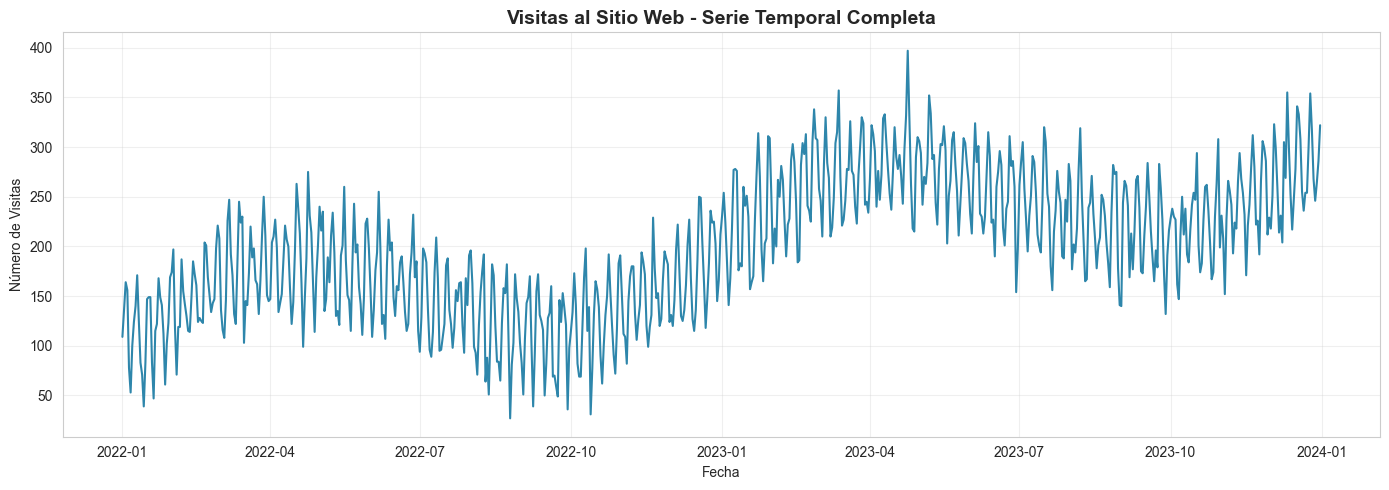

In [4]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['visitas'], linewidth=1.5, color='#2E86AB')
plt.title('Visitas al Sitio Web - Serie Temporal Completa', fontsize=14, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Número de Visitas')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Zoom en un mes específico para ver el patrón semanal
Observamos: picos los viernes y sábados

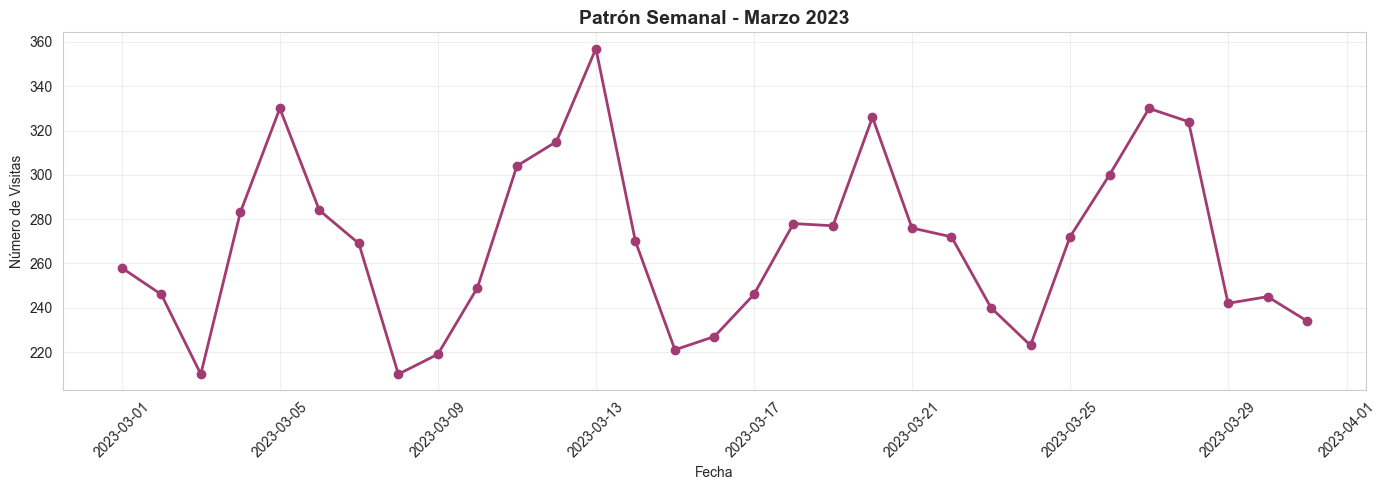

In [5]:
df_mes = df['2023-03':'2023-03']

plt.figure(figsize=(14, 5))
plt.plot(df_mes.index, df_mes['visitas'], marker='o', linewidth=2, markersize=6, color='#A23B72')
plt.title('Patrón Semanal - Marzo 2023', fontsize=14, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Número de Visitas')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Comparar el mismo mes en diferentes años
Observamos: aumento general pero patrón semanal similar

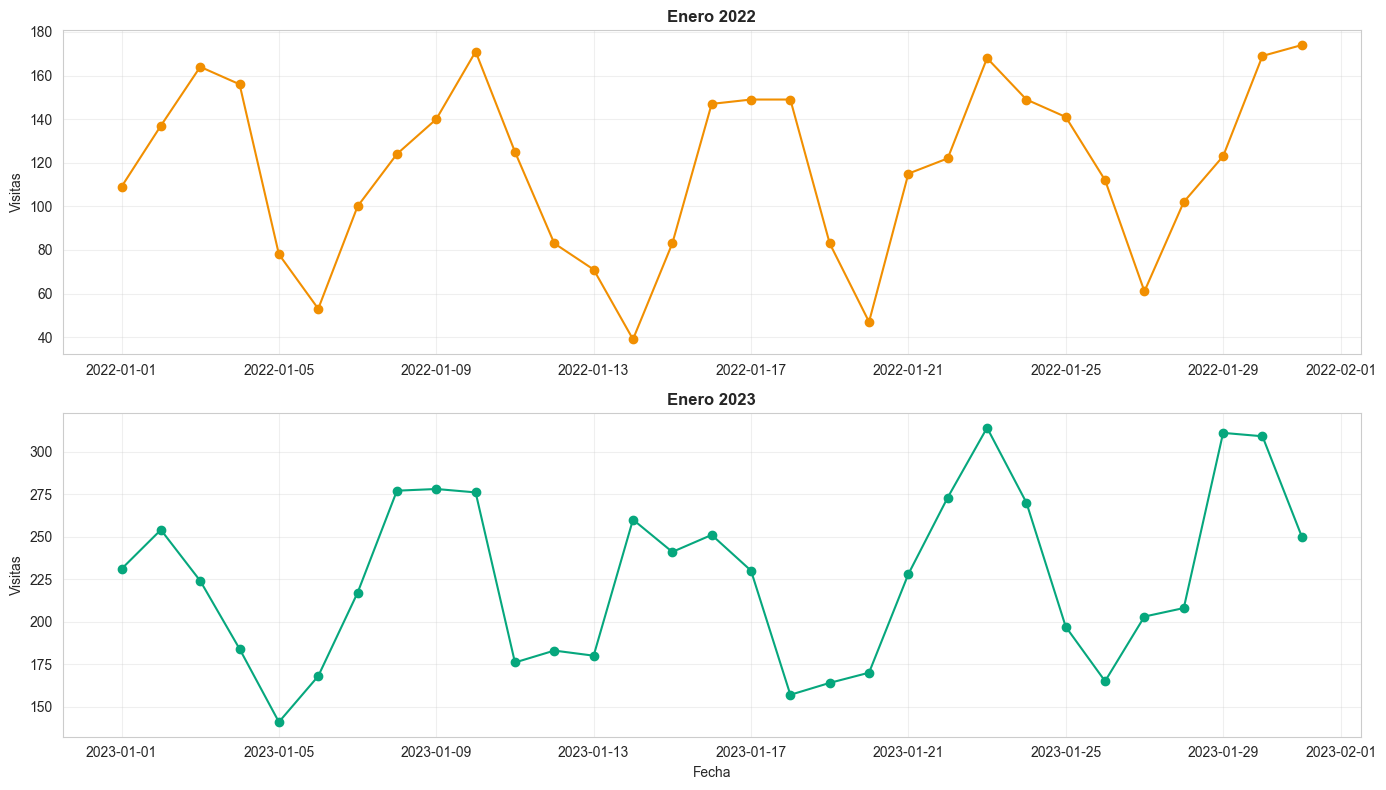

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

df_enero_2022 = df['2022-01':'2022-01']
axes[0].plot(df_enero_2022.index, df_enero_2022['visitas'], marker='o', color='#F18F01')
axes[0].set_title('Enero 2022', fontweight='bold')
axes[0].set_ylabel('Visitas')
axes[0].grid(True, alpha=0.3)

df_enero_2023 = df['2023-01':'2023-01']
axes[1].plot(df_enero_2023.index, df_enero_2023['visitas'], marker='o', color='#06A77D')
axes[1].set_title('Enero 2023', fontweight='bold')
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('Visitas')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Exploración y Análisis
Explorar el índice temporal

In [7]:
print(f'Tipo de índice: {type(df.index)}')
print(f'Rango: desde {df.index.min()} hasta {df.index.max()}')
print(f'Total de días: {len(df)}')

Tipo de índice: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Rango: desde 2022-01-01 00:00:00 hasta 2023-12-31 00:00:00
Total de días: 730


#### Acceder a componentes de la fecha

In [8]:
df['anio'] = df.index.year
df['mes'] = df.index.month
df['dia_semana'] = df.index.day_name()
#df['numero_semana'] = df.index.isocalendar().week
df['numero_semana'] = df.index.strftime('%W').astype(int) + 1

In [9]:
df.head()

,visitas,anio,mes,dia_semana,numero_semana
fecha,,,,,
2022-01-01,109,2022,1,Saturday,1
2022-01-02,137,2022,1,Sunday,1
2022-01-03,164,2022,1,Monday,2
2022-01-04,156,2022,1,Tuesday,2
2022-01-05,78,2022,1,Wednesday,2


#### Con resampling podemos agregar datos a diferentes niveles

In [10]:
# Datos diarios -> Semanales (suma)
df_semanal = df['visitas'].resample('W').sum()
print(f'Datos semanales:\n{df_semanal.head()}')

# Datos diarios -> Mensuales (promedio)
df_mensual = df['visitas'].resample('ME').mean()
print(f'\nDatos mensuales (promedio):\n{df_mensual.head()}')

# Datos diarios -> Trimestrales (máximo)
df_trimestral = df['visitas'].resample('Q').max()
print(f'\nDatos trimestrales (máximo):\n{df_trimestral.head()}')

Datos semanales:
fecha
2022-01-02    246
2022-01-09    815
2022-01-16    719
2022-01-23    833
2022-01-30    857
Freq: W-SUN, Name: visitas, dtype: int64

Datos mensuales (promedio):
fecha
2022-01-31    117.548387
2022-02-28    150.071429
2022-03-31    175.774194
2022-04-30    184.266667
2022-05-31    181.709677
Freq: ME, Name: visitas, dtype: float64

Datos trimestrales (máximo):
fecha
2022-03-31    250
2022-06-30    275
2022-09-30    209
2022-12-31    250
2023-03-31    357
Freq: QE-DEC, Name: visitas, dtype: int64


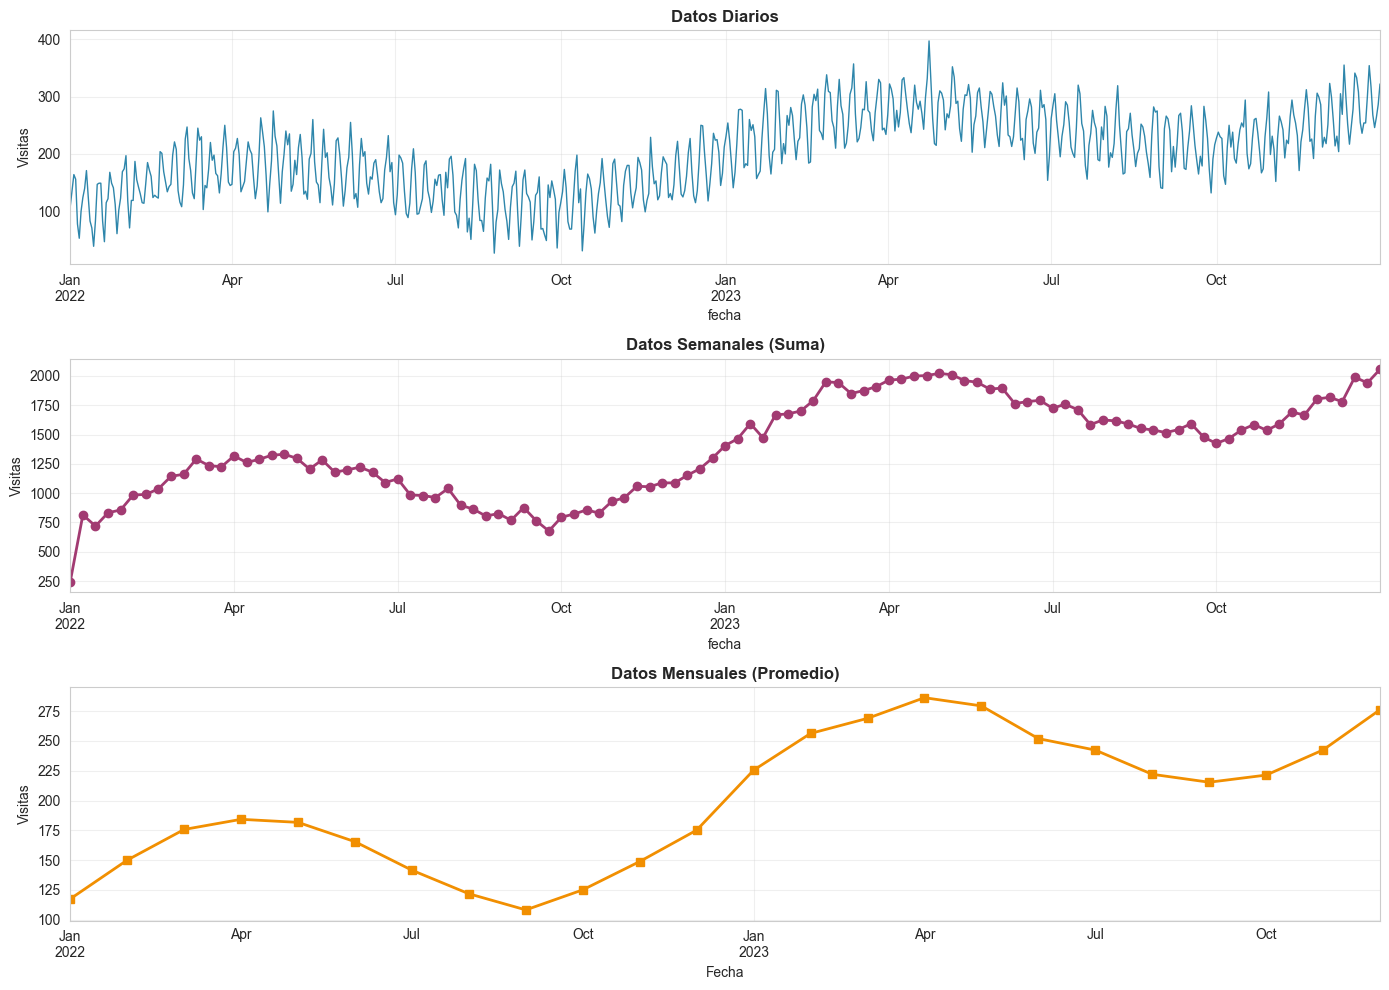

In [11]:
# Visualizar los diferentes resamplings
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Diario
df['visitas'].plot(ax=axes[0], color='#2E86AB', linewidth=1)
axes[0].set_title('Datos Diarios', fontweight='bold')
axes[0].set_ylabel('Visitas')
axes[0].grid(True, alpha=0.3)

# Semanal
df_semanal.plot(ax=axes[1], color='#A23B72', linewidth=2, marker='o')
axes[1].set_title('Datos Semanales (Suma)', fontweight='bold')
axes[1].set_ylabel('Visitas')
axes[1].grid(True, alpha=0.3)

# Mensual
df_mensual.plot(ax=axes[2], color='#F18F01', linewidth=2, marker='s')
axes[2].set_title('Datos Mensuales (Promedio)', fontweight='bold')
axes[2].set_ylabel('Visitas')
axes[2].set_xlabel('Fecha')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Análisis por grupos (Group By temporal)

Visitas por día de la semana:
                  mean        std  min  max
dia_semana                                 
Monday      244.586538  60.307885  131  397
Tuesday     221.115385  58.533089   69  330
Wednesday   175.567308  58.950986   64  297
Thursday    153.201923  62.367122   27  276
Friday      160.192308  57.513203   39  264
Saturday    199.971429  60.341569   83  305
Sunday      239.933333  59.376126  124  352


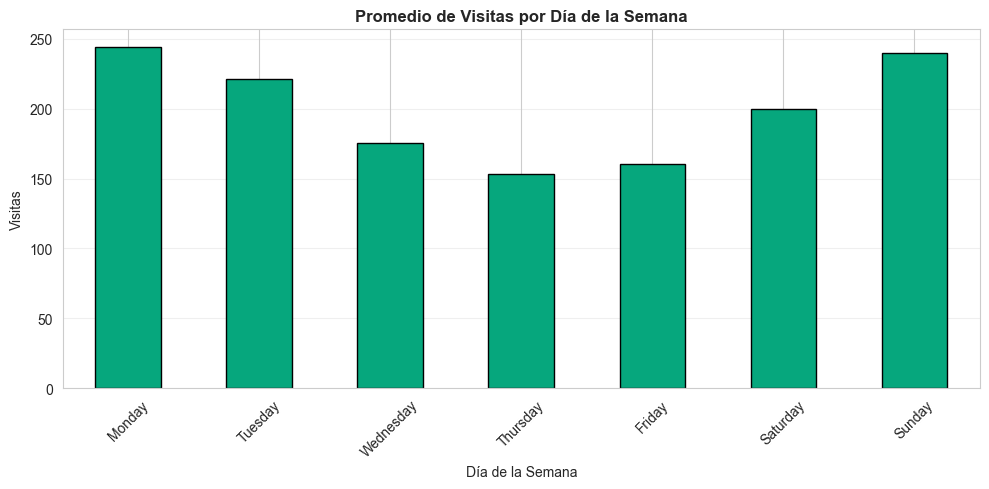

In [12]:
# Visitas promedio por día de la semana
visitas_por_dia_semana = df.groupby('dia_semana')['visitas'].agg(['mean', 'std', 'min', 'max'])
# Reordenar de lunes a domingo
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
visitas_por_dia_semana = visitas_por_dia_semana.reindex(orden_dias)
print('Visitas por día de la semana:')
print(visitas_por_dia_semana)

# Gráfico
plt.figure(figsize=(10, 5))
visitas_por_dia_semana['mean'].plot(kind='bar', color='#06A77D', edgecolor='black')
plt.title('Promedio de Visitas por Día de la Semana', fontweight='bold', fontsize=12)
plt.xlabel('Día de la Semana')
plt.ylabel('Visitas')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

#### Visitas promedio por mes


Visitas por mes:
[171.51612903 203.17857143 222.35483871 235.26666667 230.5483871
 208.73333333 191.9516129  171.93548387 161.83333333 173.24193548
 195.65       225.67741935]


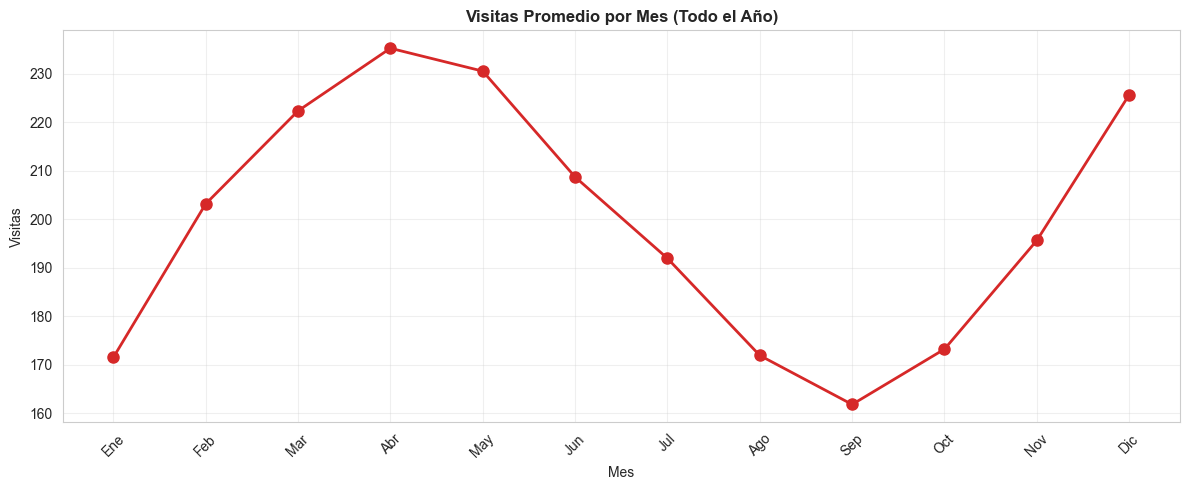

In [13]:

print('\nVisitas por mes:')
visitas_por_mes = df.groupby('mes')['visitas'].mean()
meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
print(visitas_por_mes.values)

plt.figure(figsize=(12, 5))
plt.plot(range(1, 13), visitas_por_mes.values, marker='o', linewidth=2, markersize=8, color='#D62828')
plt.title('Visitas Promedio por Mes (Todo el Año)', fontweight='bold', fontsize=12)
plt.xlabel('Mes')
plt.ylabel('Visitas')
plt.xticks(range(1, 13), meses, rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Limpieza de Datos Temporales

In [14]:
print(f'Valores faltantes: {df_problema["visitas"].isna().sum()}')

Valores faltantes: 10


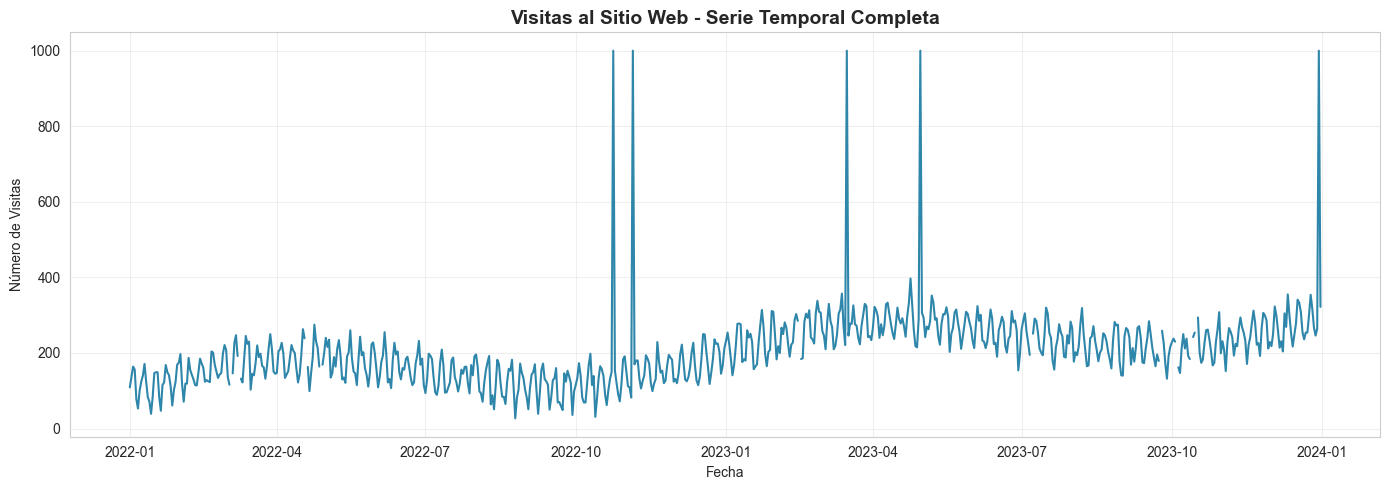

In [15]:
plt.figure(figsize=(14, 5))
plt.plot(df_problema.index, df_problema['visitas'], linewidth=1.5, color='#2E86AB')
plt.title('Visitas al Sitio Web - Serie Temporal Completa', fontsize=14, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Número de Visitas')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
df_problema[df_problema["visitas"].isna()]

,visitas
fecha,
2022-03-04,NaN
2022-03-09,NaN
2022-04-19,NaN
2022-04-28,NaN
2023-02-15,NaN
2023-07-07,NaN
2023-09-24,NaN
2023-10-04,NaN
2023-10-13,NaN


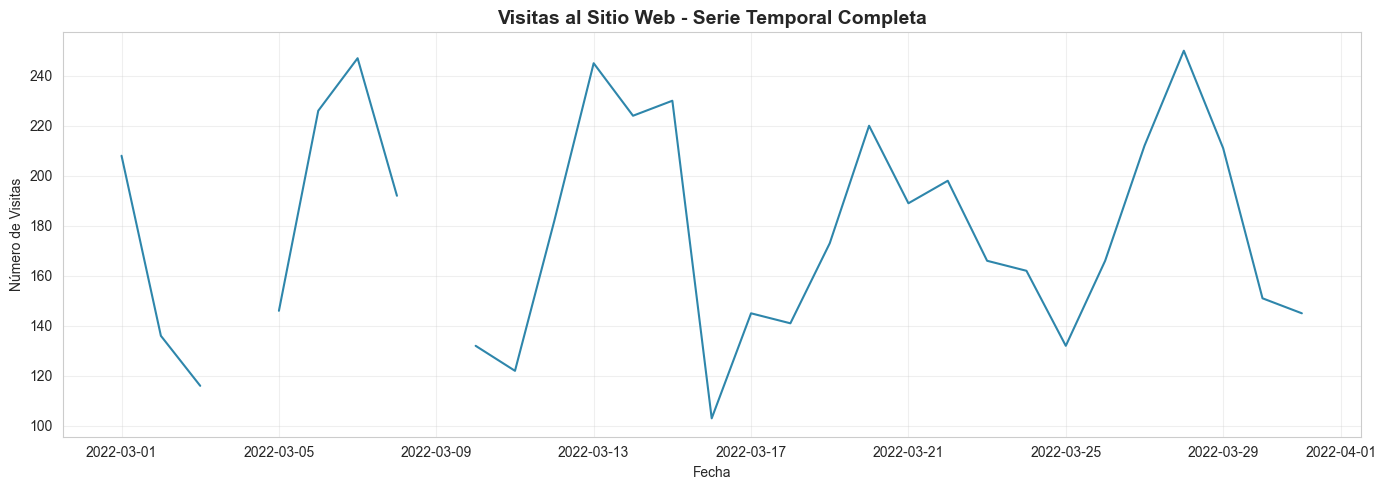

In [17]:
df_mes = df_problema['2022-03':'2022-03']

plt.plot(df_mes.index, df_mes['visitas'], linewidth=1.5, color='#2E86AB')
plt.title('Visitas al Sitio Web - Serie Temporal Completa', fontsize=14, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Número de Visitas')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Manejar valores faltantes

#### Eliminar filas con NaN

In [18]:
# Opción 1: 
df_dropna = df_problema.dropna()
print(f'Eliminar filas: {len(df_problema)} -> {len(df_dropna)} filas')

Eliminar filas: 730 -> 720 filas


#### Rellenar con el valor anterior (forward fill)

In [19]:
df_ffill = df_problema.fillna(method='ffill')
print(f'Forward Fill (repetir valor anterior): OK')

Forward Fill (repetir valor anterior): OK


#### Rellenar con interpolación lineal

In [20]:
df_interpol = df_problema.interpolate(method='linear')
print(f'Interpolación lineal: OK')

Interpolación lineal: OK


#### Rellenar con el promedio

In [21]:
df_mean = df_problema.fillna(df_problema['visitas'].mean())
print(f'Rellenar con promedio: OK')

Rellenar con promedio: OK


#### Visualizar las opciones

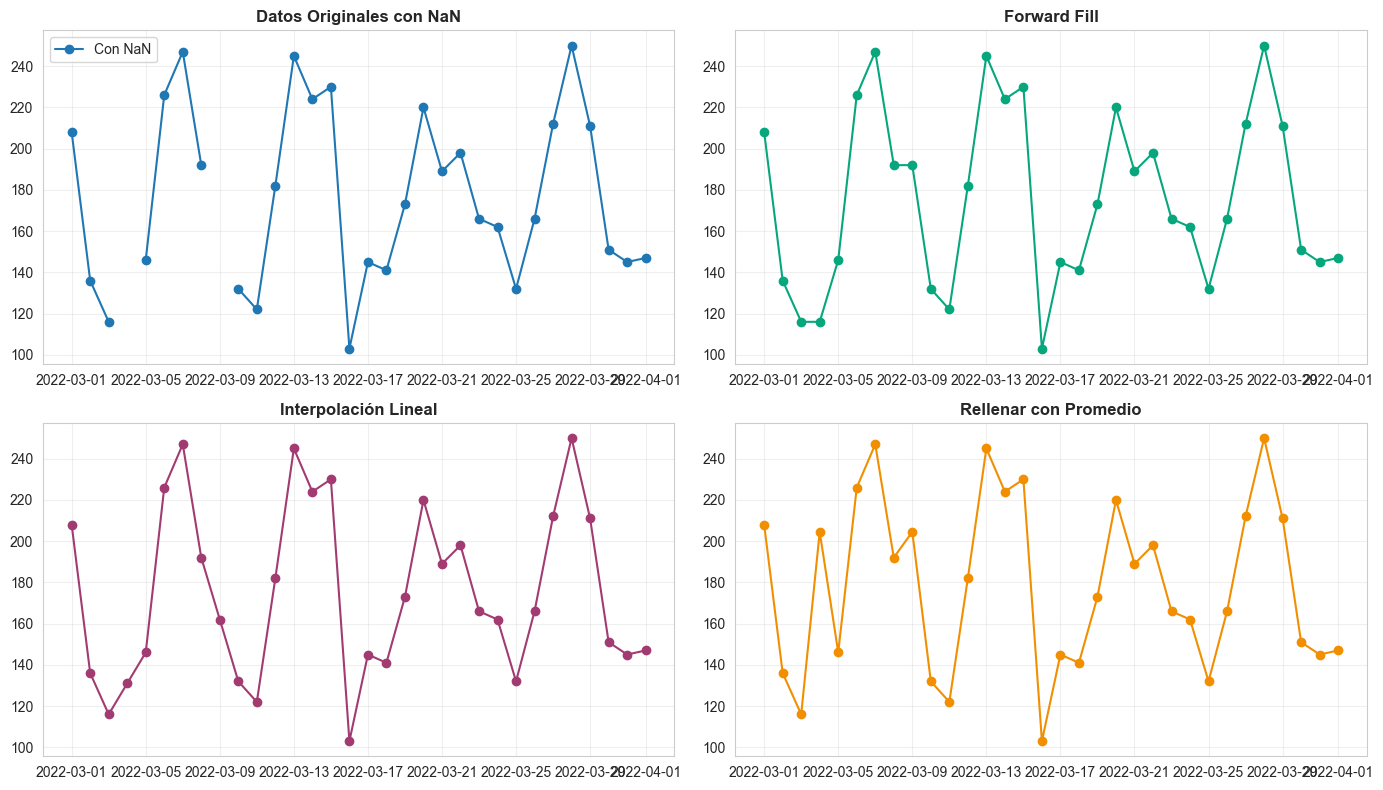

In [22]:

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

# Mostrar en rango específico
rango = slice('2022-03-01', '2022-04-01')

axes[0].plot(df_problema.loc[rango].index, df_problema.loc[rango, 'visitas'], marker='o', label='Con NaN')
axes[0].set_title('Datos Originales con NaN', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_ffill.loc[rango].index, df_ffill.loc[rango, 'visitas'], marker='o', color='#06A77D')
axes[1].set_title('Forward Fill', fontweight='bold')
axes[1].grid(True, alpha=0.3)

axes[2].plot(df_interpol.loc[rango].index, df_interpol.loc[rango, 'visitas'], marker='o', color='#A23B72')
axes[2].set_title('Interpolación Lineal', fontweight='bold')
axes[2].grid(True, alpha=0.3)

axes[3].plot(df_mean.loc[rango].index, df_mean.loc[rango, 'visitas'], marker='o', color='#F18F01')
axes[3].set_title('Rellenar con Promedio', fontweight='bold')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Detectar y manejar outliers
Si está más de 2 desviaciones estándar del promedio

Promedio: 205
Desv. Estándar: 96
Rango normal: [-82, 491]

Outliers encontrados: 5
Índices: [Timestamp('2022-10-24 00:00:00'), Timestamp('2022-11-05 00:00:00'), Timestamp('2023-03-16 00:00:00'), Timestamp('2023-04-30 00:00:00'), Timestamp('2023-12-30 00:00:00')]


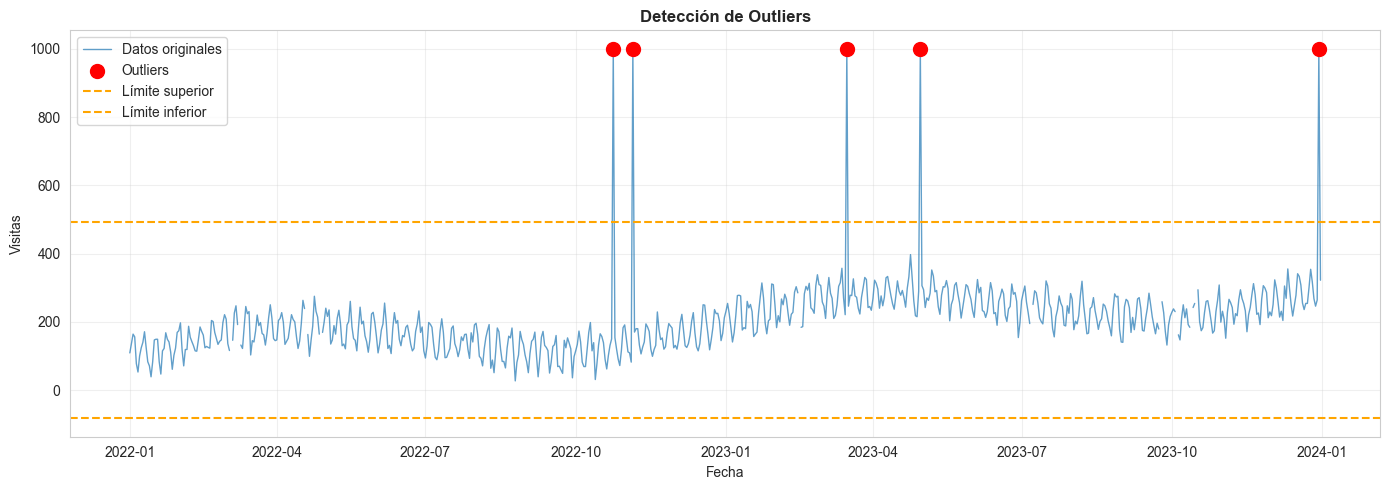

In [23]:
media = df_problema['visitas'].mean()
std = df_problema['visitas'].std()
limite_inferior = media - 3 * std
limite_superior = media + 3 * std

print(f'Promedio: {media:.0f}')
print(f'Desv. Estándar: {std:.0f}')
print(f'Rango normal: [{limite_inferior:.0f}, {limite_superior:.0f}]')

# Encontrar outliers
outliers_mask = (df_problema['visitas'] < limite_inferior) | (df_problema['visitas'] > limite_superior)
print(f'\nOutliers encontrados: {outliers_mask.sum()}')
print(f'Índices: {df_problema[outliers_mask].index.tolist()[:5]}')

# Visualizar
plt.figure(figsize=(14, 5))
plt.plot(df_problema.index, df_problema['visitas'], label='Datos originales', linewidth=1, alpha=0.7)
plt.scatter(df_problema[outliers_mask].index, df_problema[outliers_mask]['visitas'], 
           color='red', s=100, label='Outliers', zorder=5)
plt.axhline(limite_superior, color='orange', linestyle='--', label='Límite superior')
plt.axhline(limite_inferior, color='orange', linestyle='--', label='Límite inferior')
plt.title('Detección de Outliers', fontweight='bold', fontsize=12)
plt.xlabel('Fecha')
plt.ylabel('Visitas')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Limpiar datos: eliminar outliers y rellenar NaN

In [24]:
df_limpio = df_problema.copy()

# Reemplazar outliers con NaN
df_limpio.loc[outliers_mask, 'visitas'] = np.nan

# Interpolar
df_limpio['visitas'] = df_limpio['visitas'].interpolate(method='linear')

print('Dataset limpio:')
print(f'Valores faltantes: {df_limpio["visitas"].isna().sum()}')
print(f'Valores > {limite_superior:.0f}: {(df_limpio["visitas"] > limite_superior).sum()}')
print(f'\nComparación antes/después:')
print(f'Media: {df_problema["visitas"].mean():.0f} -> {df_limpio["visitas"].mean():.0f}')
print(f'Desv Est: {df_problema["visitas"].std():.0f} -> {df_limpio["visitas"].std():.0f}')

Dataset limpio:
Valores faltantes: 0
Valores > 491: 0

Comparación antes/después:
Media: 205 -> 199
Desv Est: 96 -> 69


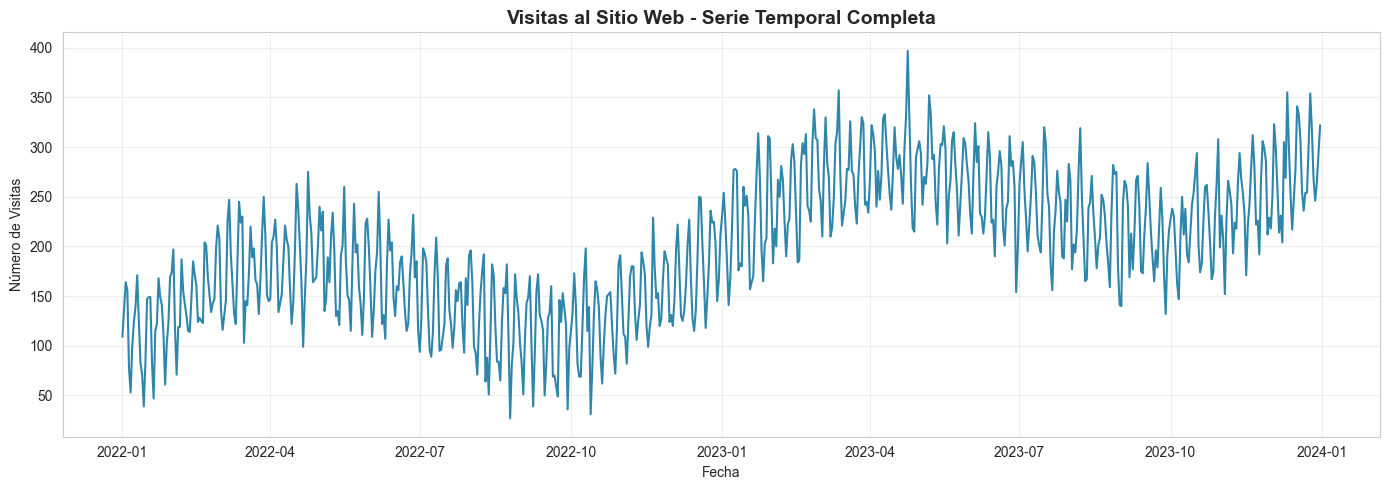

In [25]:
plt.figure(figsize=(14, 5))
plt.plot(df_limpio.index, df_limpio['visitas'], linewidth=1.5, color='#2E86AB')
plt.title('Visitas al Sitio Web - Serie Temporal Completa', fontsize=14, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Número de Visitas')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Crear Features (Características) Temporales

In [26]:
df_features = df.copy()

# 1. Extraer componentes de la fecha (ya lo hicimos, pero lo recordamos)
df_features['año'] = df_features.index.year
df_features['mes'] = df_features.index.month
df_features['día_mes'] = df_features.index.day
df_features['día_semana'] = df_features.index.dayofweek  # 0=Monday, 6=Sunday
df_features['número_semana'] = df_features.index.isocalendar().week
df_features['trimestre'] = df_features.index.quarter
df_features['es_fin_semana'] = (df_features['día_semana'] >= 5).astype(int)  # 1 si es fin de semana



In [27]:
df_features

,visitas,anio,mes,dia_semana,numero_semana,año,día_mes,día_semana,número_semana,trimestre,es_fin_semana
fecha,,,,,,,,,,,
2022-01-01,109,2022,1,Saturday,1,2022,1,5,52,1,1
2022-01-02,137,2022,1,Sunday,1,2022,2,6,52,1,1
2022-01-03,164,2022,1,Monday,2,2022,3,0,1,1,0
2022-01-04,156,2022,1,Tuesday,2,2022,4,1,1,1,0
2022-01-05,78,2022,1,Wednesday,2,2022,5,2,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...
2023-12-27,268,2023,12,Wednesday,53,2023,27,2,52,4,0
2023-12-28,246,2023,12,Thursday,53,2023,28,3,52,4,0
2023-12-29,264,2023,12,Friday,53,2023,29,4,52,4,0


### Crear features de tendencia

In [28]:
# Días desde el inicio
df_features['días_desde_inicio'] = (df_features.index - df_features.index.min()).days

# Promedio móvil (media de los últimos N días)
df_features['promedio_móvil_7'] = df_features['visitas'].rolling(window=7, min_periods=1).mean()
df_features['promedio_móvil_30'] = df_features['visitas'].rolling(window=30, min_periods=1).mean()

# Desviación estándar móvil
df_features['std_móvil_7'] = df_features['visitas'].rolling(window=7, min_periods=1).std()

# Cambio respecto al día anterior
df_features['cambio_anterior'] = df_features['visitas'].diff()

# Cambio respecto a hace una semana
df_features['cambio_semana_anterior'] = df_features['visitas'].diff(7)

In [29]:
df_features[['visitas', 'promedio_móvil_7', 'promedio_móvil_30', 'cambio_anterior']].head()

,visitas,promedio_móvil_7,promedio_móvil_30,cambio_anterior
fecha,,,,
2022-01-01,109,109.000000,109.000000,NaN
2022-01-02,137,123.000000,123.000000,28.0
2022-01-03,164,136.666667,136.666667,27.0
2022-01-04,156,141.500000,141.500000,-8.0
2022-01-05,78,128.800000,128.800000,-78.0


#### El promedio móvil nos ayuda a ver la tendencia sin el ruido

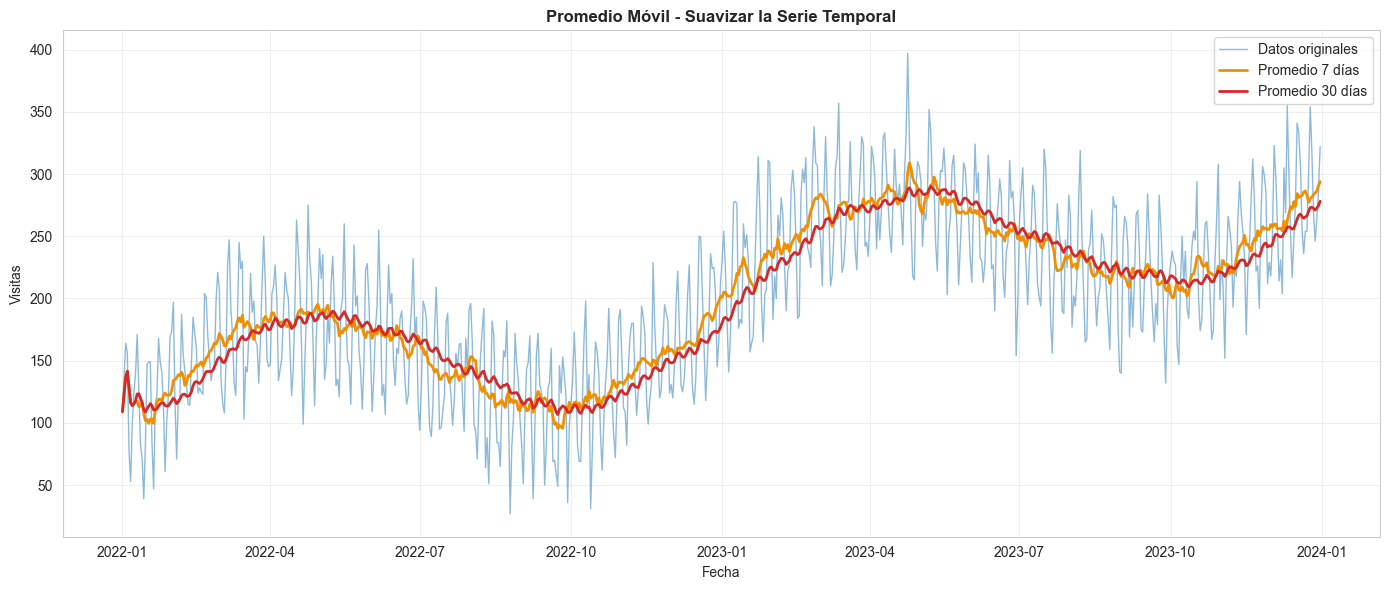

In [30]:
# Visualizar el promedio móvil
plt.figure(figsize=(14, 6))
plt.plot(df_features.index, df_features['visitas'], label='Datos originales', alpha=0.5, linewidth=1)
plt.plot(df_features.index, df_features['promedio_móvil_7'], label='Promedio 7 días', linewidth=2, color='#F18F01')
plt.plot(df_features.index, df_features['promedio_móvil_30'], label='Promedio 30 días', linewidth=2, color='#D62828')
plt.title('Promedio Móvil - Suavizar la Serie Temporal', fontweight='bold', fontsize=12)
plt.xlabel('Fecha')
plt.ylabel('Visitas')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Features de rezago (lag features) - IMPORTANTE PARA PREDICCIONES

Un rezago consiste en crear columnas nuevas que contengan los valores que tenía nuestra variable objetivo en instantes de tiempo pasados. Esto nos ayuda a la hora de usar modelos de ML tradicionales, puestos que estos no entienden el orden temporal.

Nota: Los primeros valores tienen NaN porque no hay dato anterior

In [31]:
# Valor de hace 1 día
df_features['visitas_lag_1'] = df_features['visitas'].shift(1)

# Valor de hace 7 días
df_features['visitas_lag_7'] = df_features['visitas'].shift(7)

# Valor de hace 30 días
df_features['visitas_lag_30'] = df_features['visitas'].shift(30)

# Promedio de los últimos 7 días
df_features['promedio_7_dias_pasados'] = df_features['visitas'].shift(1).rolling(window=7).mean()


df_features[['visitas', 'visitas_lag_1', 'visitas_lag_7', 'visitas_lag_30']].head()


,visitas,visitas_lag_1,visitas_lag_7,visitas_lag_30
fecha,,,,
2022-01-01,109,NaN,NaN,NaN
2022-01-02,137,109.0,NaN,NaN
2022-01-03,164,137.0,NaN,NaN
2022-01-04,156,164.0,NaN,NaN
2022-01-05,78,156.0,NaN,NaN


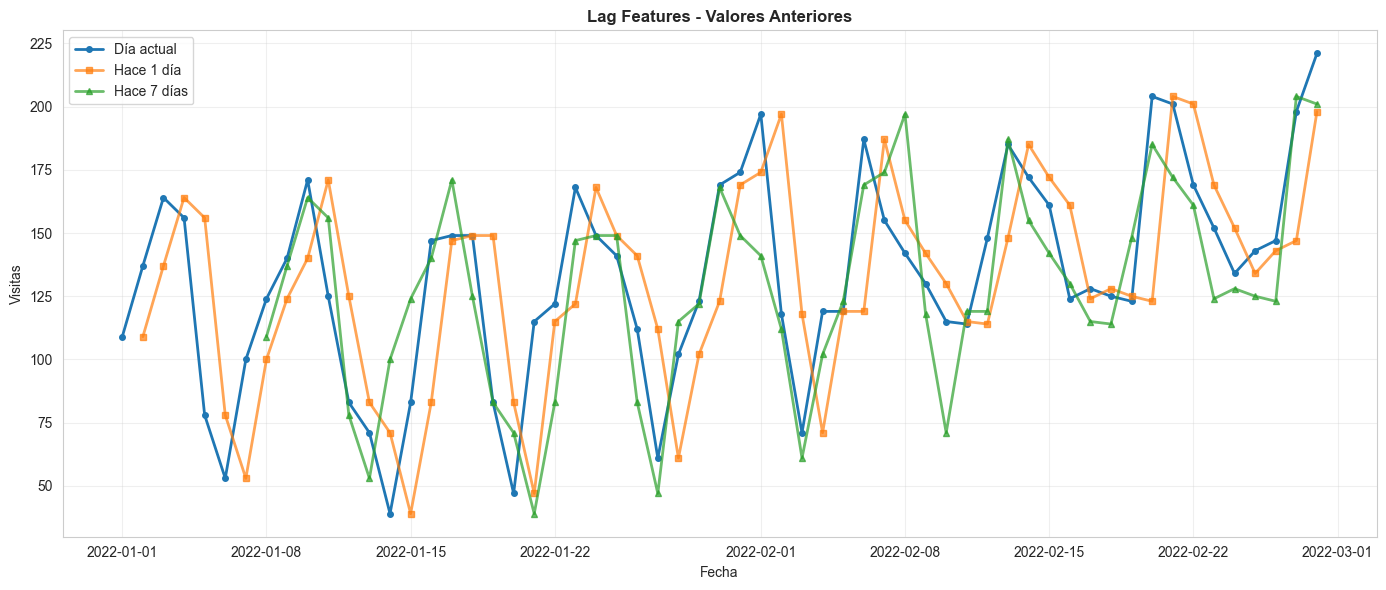

In [32]:
df_viz = df_features['2022-01':'2022-02'].copy()

plt.figure(figsize=(14, 6))
plt.plot(df_viz.index, df_viz['visitas'], marker='o', label='Día actual', linewidth=2, markersize=4)
plt.plot(df_viz.index, df_viz['visitas_lag_1'], marker='s', label='Hace 1 día', alpha=0.7, linewidth=2, markersize=4)
plt.plot(df_viz.index, df_viz['visitas_lag_7'], marker='^', label='Hace 7 días', alpha=0.7, linewidth=2, markersize=4)
plt.title('Lag Features - Valores Anteriores', fontweight='bold', fontsize=12)
plt.xlabel('Fecha')
plt.ylabel('Visitas')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [33]:
df.to_csv("data/visitas_proc_1.csv")
df_features.to_csv("data/visitas_proc_2.csv")